# CDSE OData Sentinel-2 Query & Download Workflow

Queries and downloads Sentinel-2 L1C products directly from the Copernicus Data Space Ecosystem (CDSE) OData API.  
Replaces the decommissioned OpenSearch/CDSETool workflow.

**API endpoint:** `https://catalogue.dataspace.copernicus.eu/odata/v1/`  
**Auth endpoint:** `https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token`

**Workflow:**
1. Query products by tile ID, date range, cloud cover (<30%), and product type (S2MSI1C)
2. Filter out N0500 reprocessed products (duplicates)
3. Check tile area coverage (≥50% of full tile)
4. Display thumbnail for verification (optional)
5. Download and extract selected products
6. Run ACOLITE for atmospheric correction (Rrc)

In [22]:
import os
import zipfile
import subprocess
import shutil
import requests
from datetime import date, datetime
from math import radians, sin
from glob import glob
from tqdm import tqdm
from IPython.display import Image, display

In [23]:
# ---------------------------------------------------------------------------
# Compute spherical area of a GeoJSON polygon (returns area in m²)
# ---------------------------------------------------------------------------
def calculate_area_long(polygon):
    coords = polygon['coordinates'][0]
    area = 0.0
    for i in range(len(coords)):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[(i + 1) % len(coords)]
        lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
        area += (lon2 - lon1) * (2 + sin(lat1) + sin(lat2))
    area = abs(area) * 6378137.0**2 / 2.0
    return area


# ---------------------------------------------------------------------------
# List subdirectories whose names contain a target string
# ---------------------------------------------------------------------------
def list_subdirectories_with_string(srch_dir, srch_str):
    all_subdirs = [
        os.path.join(srch_dir, d)
        for d in os.listdir(srch_dir)
        if os.path.isdir(os.path.join(srch_dir, d))
    ]
    return [d for d in all_subdirs if srch_str in d]


# ---------------------------------------------------------------------------
# Extract a named attribute value from an OData product's Attributes list
# ---------------------------------------------------------------------------
def get_attribute(product, attr_name):
    for attr in product.get('Attributes', []):
        if attr['Name'] == attr_name:
            return attr['Value']
    return None

In [24]:
# ---------------------------------------------------------------------------
# Query CDSE OData catalogue for Sentinel-2 L1C products
#
# Filters applied server-side:
#   - Collection: SENTINEL-2
#   - productType: S2MSI1C  (L1C only)
#   - tileId: exact UTM tile (e.g. '22VFN')
#   - ContentDate: within [date_from, date_to]
#   - cloudCover: < cloud_cover_max  (percent, 0-100)
#
# Returns a list of product dicts with Attributes expanded.
# Handles OData pagination automatically ($top=100 per page).
# ---------------------------------------------------------------------------
def query_sentinel2_odata(tile_id, date_from, date_to, cloud_cover_max=30):
    base_url = 'https://catalogue.dataspace.copernicus.eu/odata/v1/Products'

    date_from_str = date_from.strftime('%Y-%m-%dT00:00:00.000Z')
    date_to_str   = date_to.strftime('%Y-%m-%dT23:59:59.000Z')

    filter_parts = [
        "Collection/Name eq 'SENTINEL-2'",
        "Attributes/OData.CSC.StringAttribute/any("
            "att:att/Name eq 'productType' and "
            "att/OData.CSC.StringAttribute/Value eq 'S2MSI1C')",
        f"Attributes/OData.CSC.StringAttribute/any("
            f"att:att/Name eq 'tileId' and "
            f"att/OData.CSC.StringAttribute/Value eq '{tile_id}')",
        f"ContentDate/Start gt {date_from_str}",
        f"ContentDate/Start lt {date_to_str}",
        f"Attributes/OData.CSC.DoubleAttribute/any("
            f"att:att/Name eq 'cloudCover' and "
            f"att/OData.CSC.DoubleAttribute/Value lt {cloud_cover_max:.2f})",
    ]

    params = {
        '$filter':  ' and '.join(filter_parts),
        '$expand':  'Attributes',
        '$orderby': 'ContentDate/Start desc',
        '$count':   'true',
        '$top':     100,
    }

    all_products = []
    print(f'Querying tile {tile_id}  {date_from} → {date_to}  (cloud < {cloud_cover_max}%)')

    while True:
        params['$skip'] = len(all_products)
        resp = requests.get(base_url, params=params, timeout=60)
        resp.raise_for_status()
        data = resp.json()

        page = data.get('value', [])
        all_products.extend(page)

        total = data.get('@odata.count', '?')
        print(f'  Retrieved {len(all_products)} / {total} products')

        if len(page) < 100:
            break

    return all_products

In [25]:
# ---------------------------------------------------------------------------
# Obtain an OAuth2 access token from the CDSE identity service
# ---------------------------------------------------------------------------
def get_access_token(username, password):
    token_url = (
        'https://identity.dataspace.copernicus.eu'
        '/auth/realms/CDSE/protocol/openid-connect/token'
    )
    payload = {
        'client_id':  'cdse-public',
        'grant_type': 'password',
        'username':   username,
        'password':   password,
    }
    resp = requests.post(token_url, data=payload, timeout=30)
    resp.raise_for_status()
    token = resp.json()['access_token']
    print('Access token obtained.')
    return token


# ---------------------------------------------------------------------------
# Download a product by its OData ID, with a progress bar.
# The .zip is extracted in-place and the archive is deleted.
# ---------------------------------------------------------------------------
def download_product(product_id, product_name, download_path, access_token):
    url = (
        f'https://catalogue.dataspace.copernicus.eu'
        f'/odata/v1/Products({product_id})/$value'
    )
    headers = {'Authorization': f'Bearer {access_token}'}
    os.makedirs(download_path, exist_ok=True)
    zip_path = os.path.join(download_path, f'{product_name}.zip')

    with requests.Session() as session:
        session.headers.update(headers)
        resp = session.get(url, stream=True, allow_redirects=True, timeout=600)
        resp.raise_for_status()

        total = int(resp.headers.get('content-length', 0))
        with open(zip_path, 'wb') as fh, tqdm(
            total=total, unit='B', unit_scale=True, desc=product_name
        ) as pbar:
            for chunk in resp.iter_content(chunk_size=65536):
                fh.write(chunk)
                pbar.update(len(chunk))

    print(f'Extracting {product_name} ...')
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(download_path)
    os.remove(zip_path)
    print(f'Done → {download_path}\n')

In [26]:
# ---------------------------------------------------------------------------
# Display the QUICKLOOK thumbnail for a product.
# Assets are fetched via a separate single-product request ($expand=Assets),
# which the CDSE API supports — unlike expanding multiple entities in a
# collection query.  URL format per CDSE documentation:
#   https://catalogue.dataspace.copernicus.eu/odata/v1/Assets({asset_id})/$value
# ---------------------------------------------------------------------------
def show_thumbnail(product_id, product_name):
    url = f'https://catalogue.dataspace.copernicus.eu/odata/v1/Products({product_id})'
    try:
        resp = requests.get(url, params={'$expand': 'Assets'}, timeout=30)
        resp.raise_for_status()
        assets = resp.json().get('Assets', [])
        ql = next((a for a in assets if a.get('Type') == 'QUICKLOOK'), None)
        if not ql:
            print('  (no QUICKLOOK asset found)')
            return
        tn_url = (
            f"https://catalogue.dataspace.copernicus.eu"
            f"/odata/v1/Assets({ql['Id']})/$value"
        )
        img_data = requests.get(tn_url, timeout=30).content
        print(f'  Thumbnail: {tn_url}')
        display(Image(data=img_data, width=400))
    except Exception as e:
        print(f'  (thumbnail unavailable: {e})')

In [27]:
# ---------------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------------

download_path = '/data/S2_CDSE/S2_download/'

username = 'your_cdse_email@example.com'
password = 'your_password'

# Set dld = True to download products that pass all filters.
# Set dld = False to query only (inspect results before committing to download).
dld = False

tile_id        = '22VFN'   # UTM tile ID
cloud_max      = 30        # maximum cloud cover (%)
tile_pct       = 0.5       # minimum fraction of full tile that must be covered
show_tn        = True      # display quicklook thumbnails in notebook

y = 2024
m = 5

# Each entry is [day_start, day_end] (inclusive) within the month above.
if not dld:
    date_list = [[1, 31]]        # scan the whole month when just browsing
else:
    date_list = [[23, 24], [15, 17], [3, 4]]

# Reference area of a full 110 km × 110 km Sentinel-2 tile (m²)
full_tile_area = (110 * 1000) ** 2

Querying tile 22VFN  2024-05-01 → 2024-05-31  (cloud < 30%)
  Retrieved 10 / 10 products
S2A_MSIL1C_20240525T143001_N0510_R139_T22VFN_20240525T180921.SAFE
  Cloud cover : 7.2%
  Tile coverage: 70.7%
  Acquisition : 2024-05-25
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(35da40e2-f7f6-4291-89f8-28aec892bf63)/$value


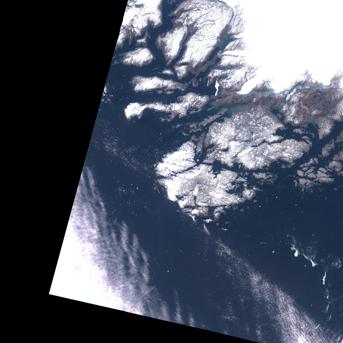


S2B_MSIL1C_20240523T143749_N0510_R039_T22VFN_20240523T164040.SAFE
  Cloud cover : 3.2%
  Tile coverage: 99.3%
  Acquisition : 2024-05-23
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(ad015f4b-e310-4a6c-a852-21166e257bdc)/$value


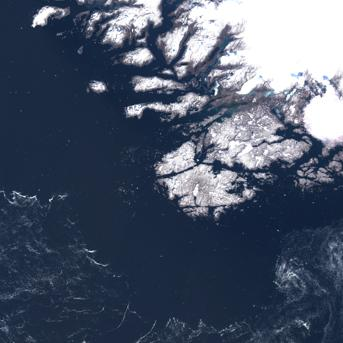


S2A_MSIL1C_20240518T143751_N0510_R039_T22VFN_20240521T131719.SAFE
  Cloud cover : 7.5%
  Tile coverage: 99.3%
  Acquisition : 2024-05-18
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(6c8c8fab-de09-43a7-9128-6d24ce1b6a1e)/$value


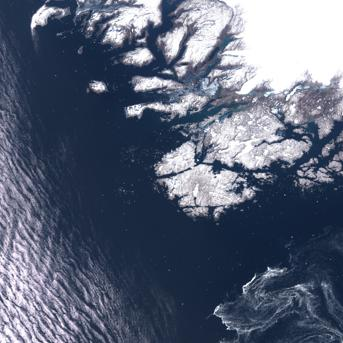


S2B_MSIL1C_20240516T144749_N0510_R082_T22VFN_20240516T200942.SAFE
  Cloud cover : 4.7%
  Tile coverage: 59.3%
  Acquisition : 2024-05-16
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(444e5288-dfd4-4e22-9111-8cb2098e0498)/$value


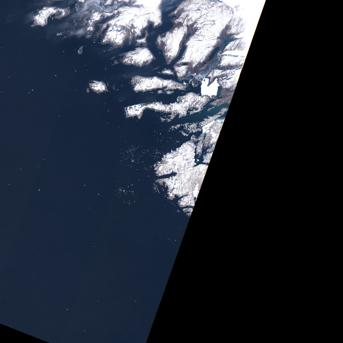


S2A_MSIL1C_20240515T143011_N0510_R139_T22VFN_20240515T194823.SAFE
  Cloud cover : 3.7%
  Tile coverage: 76.3%
  Acquisition : 2024-05-15
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(13a0823d-f5be-44c0-8bc0-243bb4bde9f7)/$value


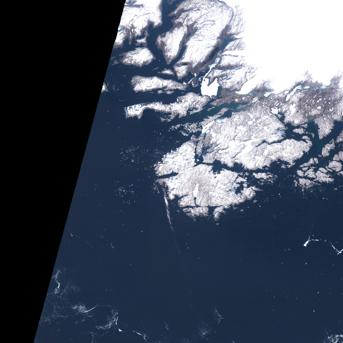


S2B_MSIL1C_20240510T142739_N0510_R139_T22VFN_20240510T162934.SAFE
  Cloud cover : 24.6%
  Tile coverage: 76.3%
  Acquisition : 2024-05-10
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(9c7c5329-b530-4696-beaf-fe7f34475270)/$value


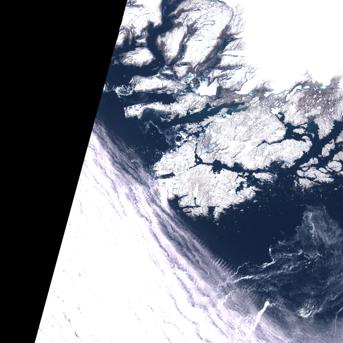


S2B_MSIL1C_20240506T144749_N0510_R082_T22VFN_20240506T164901.SAFE
  Cloud cover : 4.6%
  Tile coverage: 58.6%
  Acquisition : 2024-05-06
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(c6bce397-2a15-45ae-a5d1-d6ac14da04c7)/$value


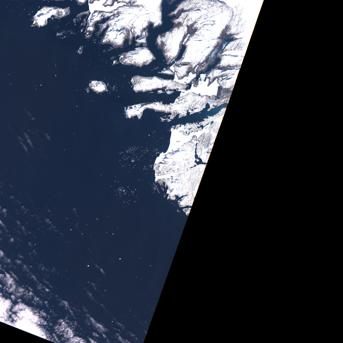


S2A_MSIL1C_20240505T143011_N0510_R139_T22VFN_20240505T182553.SAFE
  Cloud cover : 5.1%
  Tile coverage: 76.3%
  Acquisition : 2024-05-05
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(94f7a215-6643-4a99-8cff-1e388b89280a)/$value


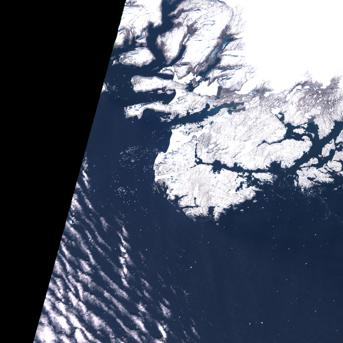


S2B_MSIL1C_20240503T143749_N0510_R039_T22VFN_20240503T163940.SAFE
  Cloud cover : 8.9%
  Tile coverage: 99.3%
  Acquisition : 2024-05-03
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(42256237-339c-4189-842e-3dfe03f8e41e)/$value


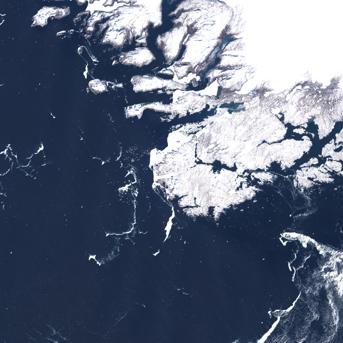


S2A_MSIL1C_20240501T144951_N0510_R082_T22VFN_20240501T183435.SAFE
  Cloud cover : 1.4%
  Tile coverage: 58.2%
  Acquisition : 2024-05-01
  Thumbnail: https://catalogue.dataspace.copernicus.eu/odata/v1/Assets(34342ce4-af69-45c7-965d-846be3a2fae6)/$value


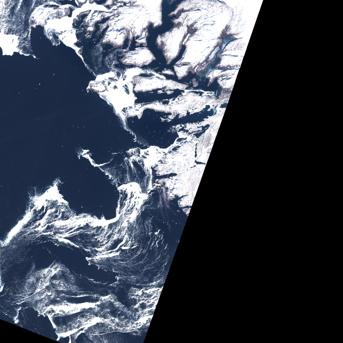

In [28]:
# ---------------------------------------------------------------------------
# Main query and (optionally) download loop
# ---------------------------------------------------------------------------

if dld:
    access_token = get_access_token(username, password)
else:
    access_token = None

for dent in date_list:
    date_from = date(y, m, dent[0])
    # Guard against months with fewer than 31 days
    try:
        date_to = date(y, m, dent[1])
    except ValueError:
        date_to = date(y, m, dent[1] - 1)

    products = query_sentinel2_odata(
        tile_id, date_from, date_to, cloud_cover_max=cloud_max
    )

    if not products:
        print('  No products found for this date window.\n')
        continue

    for product in products:
        name   = product['Name']
        pid    = product['Id']
        cc     = get_attribute(product, 'cloudCover') or 0.0
        fgeo   = product.get('GeoFootprint')

        # --- Exclude N0500 reprocessed products (creates duplicates) ---
        if 'N0500' in name:
            continue

        # --- Tile coverage check ---
        if fgeo is None:
            print(f'  {name}: no footprint geometry, skipping.')
            continue

        tile_area = calculate_area_long(fgeo)
        coverage  = tile_area / full_tile_area

        if coverage < tile_pct:
            continue

        # --- Print summary ---
        print(f'{name}')
        print(f'  Cloud cover : {float(cc):.1f}%')
        print(f'  Tile coverage: {coverage * 100:.1f}%')
        acq_date = product['ContentDate']['Start'][:10]
        print(f'  Acquisition : {acq_date}')

        # --- Optional thumbnail ---
        if show_tn:
            show_thumbnail(pid, name)

        # --- Download ---
        if dld:
            safe_dir = os.path.join(download_path, name)
            if os.path.isdir(safe_dir):
                print(f'  Already downloaded, skipping.\n')
                continue
            print(f'  Downloading to {download_path}')
            download_product(pid, name, download_path, access_token)
        else:
            print()

---
## ACOLITE — atmospheric correction (Rrc)

Run after downloading L1C `.SAFE` directories.  
Produces Rayleigh-corrected reflectance (Rrc) NetCDF files with residual sunglint correction.

In [ ]:
# ---------------------------------------------------------------------------
# ACOLITE settings and batch run
# ---------------------------------------------------------------------------

acolite_dir  = '/home/Documents/acolite_py_linux/'
acolite_out  = '/data/S2_CDSE/S2_acolite/'
settings_fnm = os.path.join(acolite_dir, 'greenfloat_settings.txt')

set_str = [
    'EARTHDATA_u=your_earthdata_username',
    'EARTHDATA_p=your_earthdata_password',
    f'output={acolite_out}',
    's2_target_res=10',
    'output_rhorc=True',
    'dsf_residual_glint_correction=True',
    'dsf_residual_glint_correction_method=default',
]

l1c_dirs = list_subdirectories_with_string(download_path, '.SAFE')
print(f'Found {len(l1c_dirs)} .SAFE directories.')

os.chdir(acolite_dir)

for l1c in l1c_dirs:
    with open(settings_fnm, 'w') as fh:
        fh.write(f'inputfile={l1c}\n')
        for s in set_str:
            fh.write(f'{s}\n')

    print(f'Running ACOLITE on {os.path.basename(l1c)} ...')
    subprocess.run(
        'dist/acolite/acolite --cli --settings=greenfloat_settings.txt',
        shell=True, check=True
    )
    print('And... Done.\n')

---
## Optional: zip processed L1C directories and clean up

In [ ]:
# ---------------------------------------------------------------------------
# Re-zip each .SAFE directory into the 'processed' sub-folder, then delete.
# Uncomment to run.
# ---------------------------------------------------------------------------

processed_dir = os.path.join(download_path, 'processed')
os.makedirs(processed_dir, exist_ok=True)

l1c_dirs = list_subdirectories_with_string(download_path, '.SAFE')

# for l1c in l1c_dirs:
#     base = os.path.basename(os.path.normpath(l1c)).split('.')[0]
#     zip_out = os.path.join(processed_dir, base)
#     print(f'Zipping {base} ...')
#     shutil.make_archive(zip_out, 'zip', l1c)
#     shutil.rmtree(l1c)
#     print(f'  Saved to {zip_out}.zip')